# DynamicPATCH workshop 

## Presentation

[Open the presentation slides](https://github.com/zay1996/Workshop_GIStimeseries/raw/main/assets/slides/workshop_DynamicPATCH.pptx){.btn .btn-primary target="_blank"}



In this tutorial you will use **DynamicPATCH** to characterize marsh transitions at the Virginia Coast Reserve (VCR) between 1985 and 2021.

By the end, you will be able to:

1. install the DynamicPATCH developer branch;
2. run a DynamicPATCH transition analysis; and
3. interpret the transition map and four summary tables.

## 1. Install DynamicPATCH

DynamicPATCH recommends **Python 3.10**. Run the next cell once to install the current `developer-branch` directly from GitHub into this notebook's Python environment.

If the installation reports that `git` is missing, install Git from <https://git-scm.com/downloads> or run `conda install -c anaconda git` in Anaconda Prompt, then run the cell again.

In [18]:
%pip install --upgrade "git+https://github.com/zay1996/DynamicPATCH.git@developer-branch"

Note: you may need to restart the kernel to use updated packages.Collecting git+https://github.com/zay1996/DynamicPATCH.git@developer-branch
  Cloning https://github.com/zay1996/DynamicPATCH.git (to revision developer-branch) to C:\Users\AiZhang\AppData\Local\Temp\pip-req-build-hxom51fr
  Resolved https://github.com/zay1996/DynamicPATCH.git to commit 64f4778e88669d3e11b810a5cf748eebc54eecb7
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'



  Running command git clone --filter=blob:none --quiet https://github.com/zay1996/DynamicPATCH.git 'C:\Users\AiZhang\AppData\Local\Temp\pip-req-build-hxom51fr'
  Running command git checkout -b developer-branch --track origin/developer-branch
  branch 'developer-branch' set up to track 'origin/developer-branch'.
  Switched to a new branch 'developer-branch'


If your notebook asks you to restart the kernel after installation, restart it and continue with the next cell. You do not need to run the installation cell again.

In [19]:
import dynamicpatch
from pathlib import Path
import numpy as np
import pandas as pd
print("DynamicPATCH version:", metadata.version("dynamicpatch"))

DynamicPATCH version: 0.2.0


## 2. Access the VCR data
The VCR raster data are included in the workshop GitHub repository. Run the setup cell below to clone the repository:

In [29]:
!git clone https://github.com/zay1996/Workshop_GIStimeseries.git
%cd Workshop_GIStimeseries

c:\OneDrive - Clark University\Desktop\Research\HarvardCGAworkshop\dynamicpatch-workshop\Workshop_GIStimeseries


Cloning into 'Workshop_GIStimeseries'...
c:\Users\AiZhang\AppData\Local\miniconda3\envs\dynamic\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [30]:
# Change only this line if you stored the VCR rasters somewhere else.
data_dir = Path("data")

input_files = sorted(data_dir.glob("*.tif"))
print("Input files:", [path.name for path in input_files])

Input files: ['1990.tif', '2000.tif', '2010.tif', '2020.tif']


You should see `['1990.tif', '2000.tif','2010.tif','2020.tif']`. DynamicPATCH reads folder inputs in filename order, so the `year` list must follow the same temporal order.

### VCR class values

| Value | Land-cover class |
|---:|---|
| 1 | Trees |
| 2 | Marsh |
| 3 | Beach |
| 4 | Water |
| 255 | NoData |

This demonstration treats **marsh (`2`)** as presence and every other valid land-cover class as absence.

## 3. Run DynamicPATCH

The complete VCR analysis is one function call.

| Argument | Workshop value | Meaning | 
|---|---|---|
| `workpath*` | `data_dir` | Folder containing the input maps |
| `year*` | `[1990, 2000, 2010, 2020]` | Years corresponding to the maps, in temporal order |
| `targ_pre*` | `2` | Pixel value treated as presence: marsh |
| `in_nodata` | `255` | Pixel value treated as NoData |
| `connectivity` | `8` | Queen connectivity; pixels may connect by an edge or corner |
| `study_area` | `"VCR marsh"` | Label used in outputs |
| `unit` | `"pixels"` | Report area in number of pixels |
| `res` | `30` | Raster cell size in meters |
| `export_map` | `None` | Do not export a GeoTIFF during this run |
&#42; These arguments are mandatory. 

Other useful options from the package are:

| Argument | Purpose |
|---|---|
| `unit` | Use `"pixels"`, `"sqm2"`, `"km2"`, or `"Default"` |
| `log_scale` | Control the logarithmic patch-size chart; the current version supports log scale |
| `width` | Change the width of bars in the result charts |
| `rotation` | Rotate year labels in stacked bar charts |
| `export_map` | Supply an output prefix without `.tif`, or use `None` to skip export |

data loaded
Running Transition Analysis on time interval 0
Running Transition Analysis on time interval 1
Running Transition Analysis on time interval 2
areaunit = pixels,size_map = 9,res = 30
width is  0.2333333333333333 3
width is  0.2333333333333333 3


c:\Users\AiZhang\AppData\Local\miniconda3\envs\dynamic\lib\site-packages\dynamicpatch\create_charts.py:243: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(bottom=0)


xlabelsize 18 3
['1990' '2000' '2010' '2020']


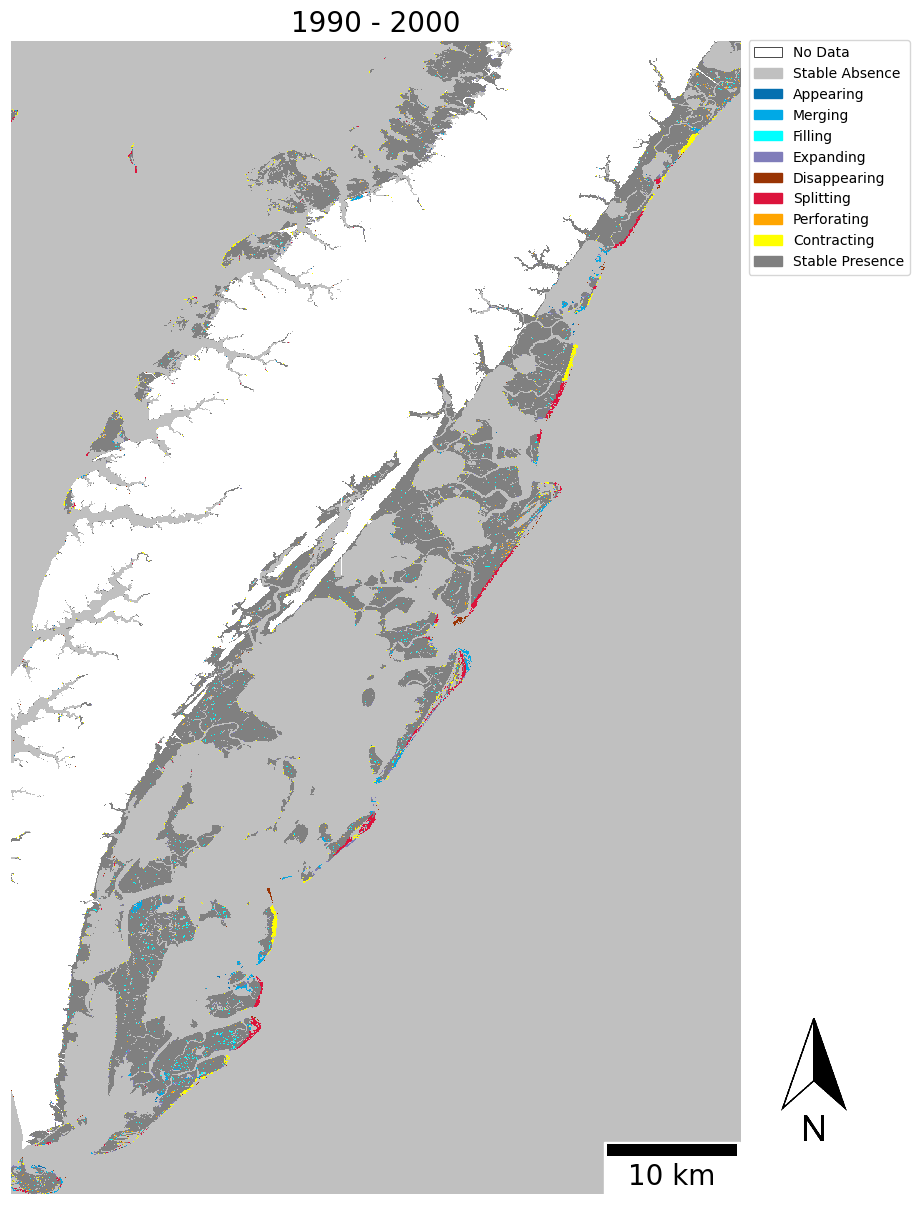

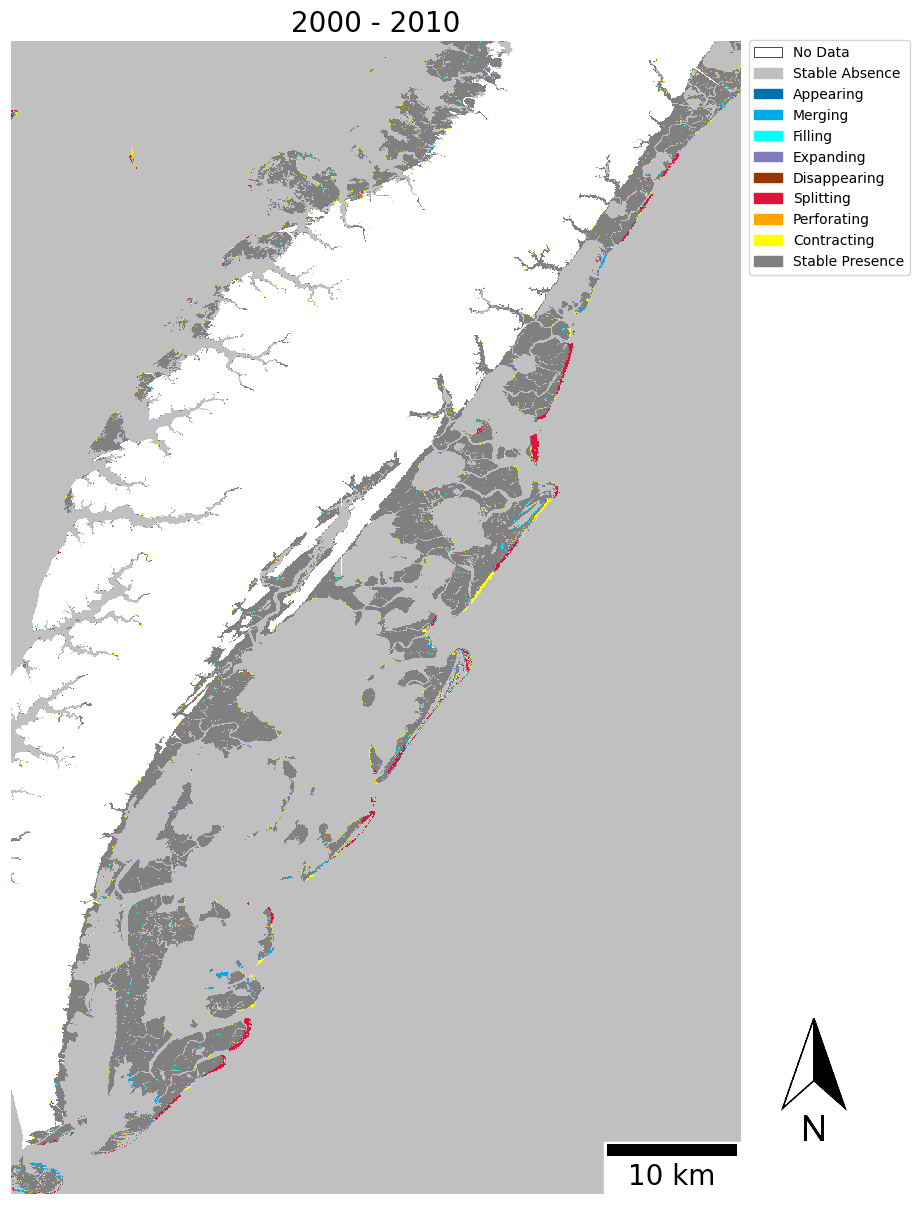

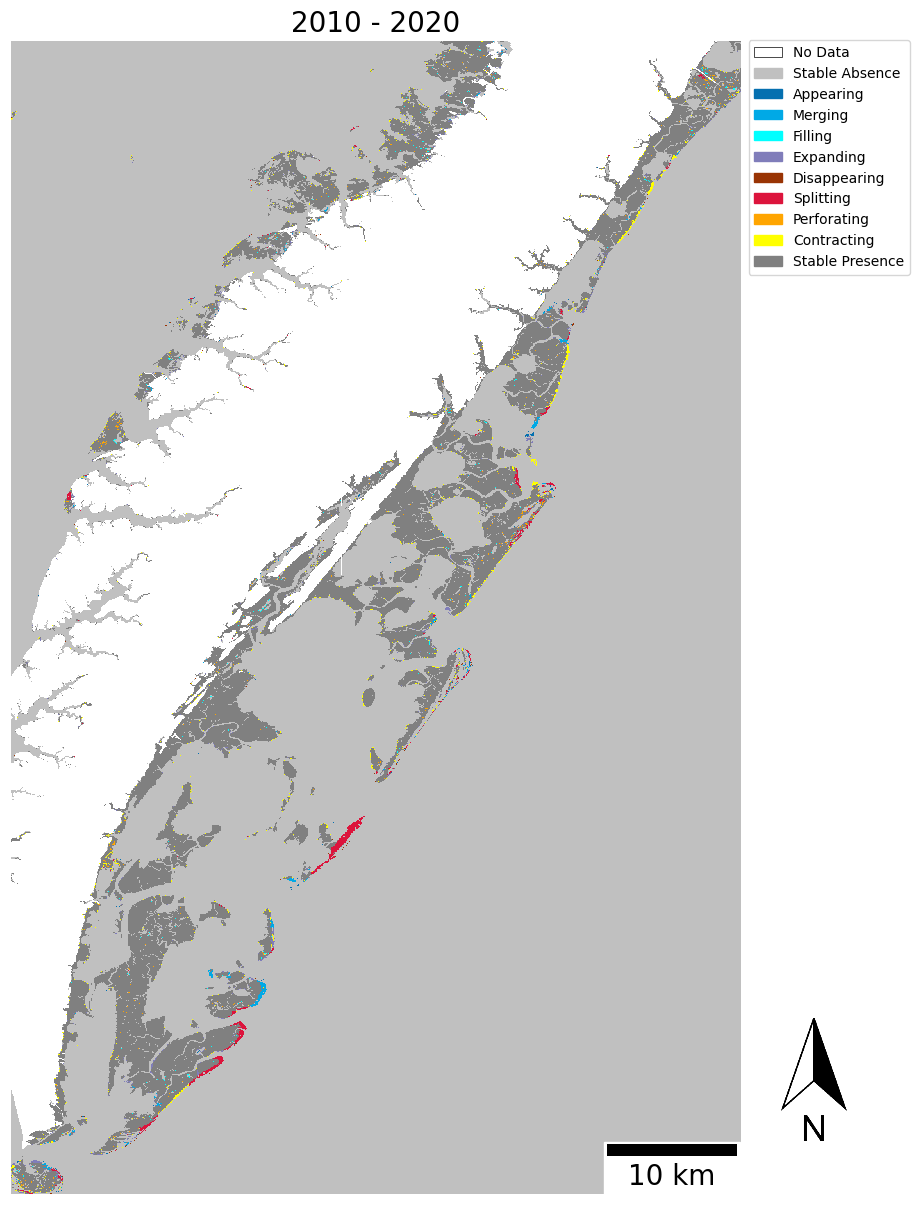

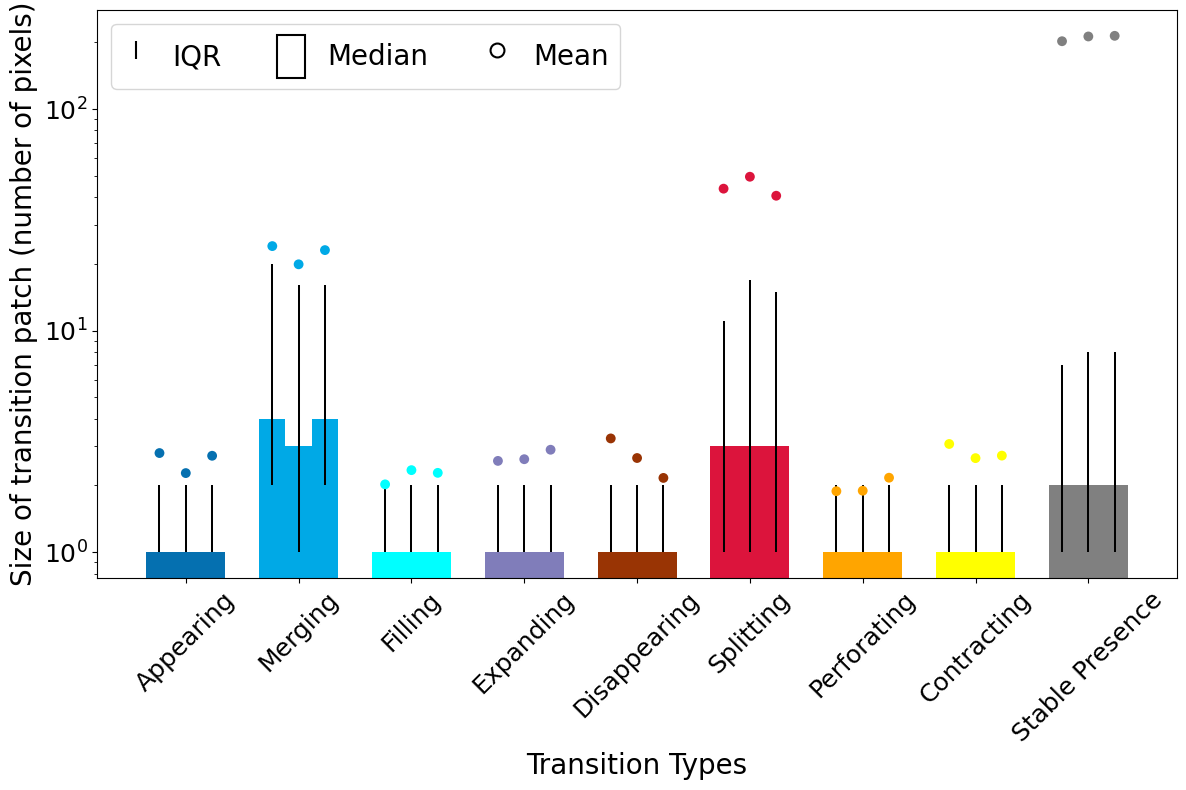

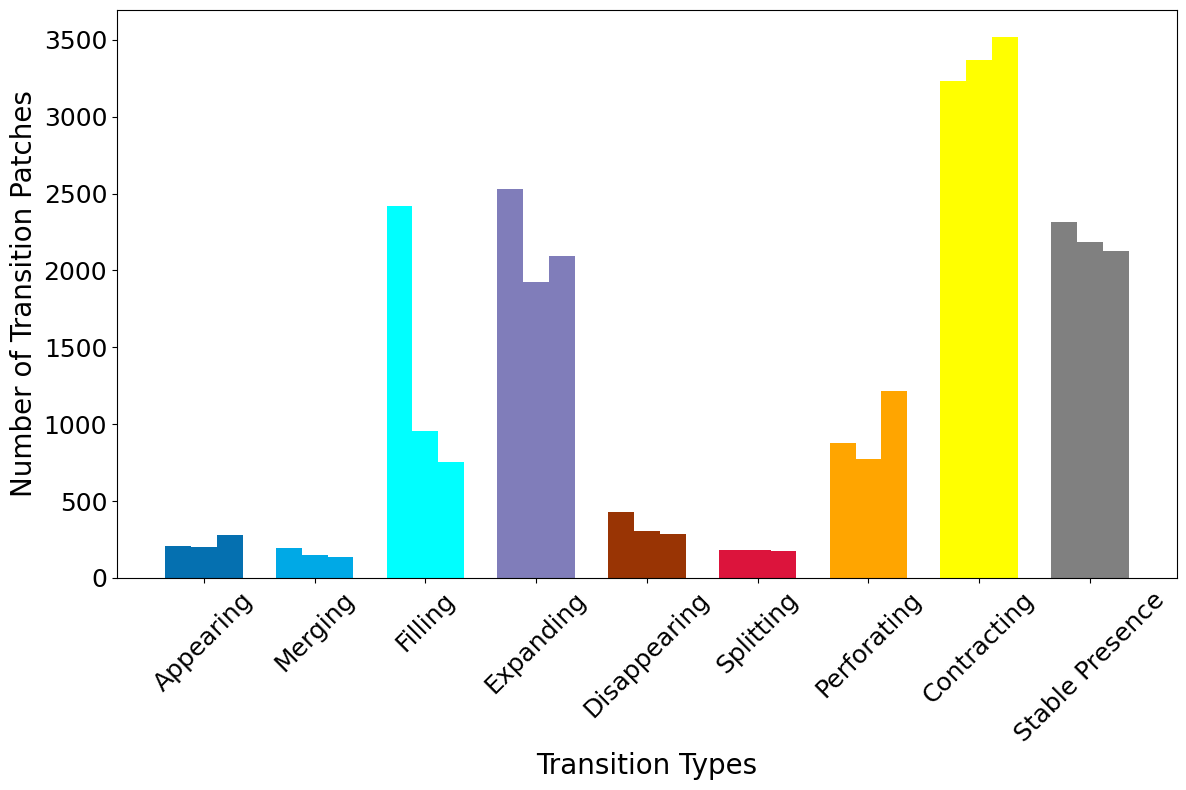

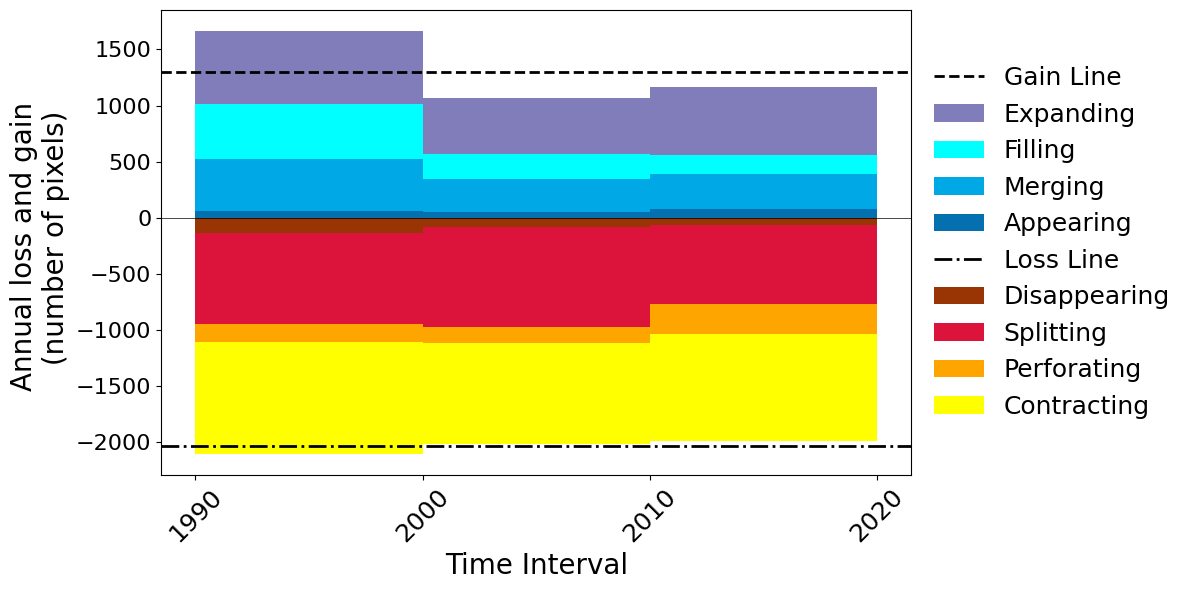

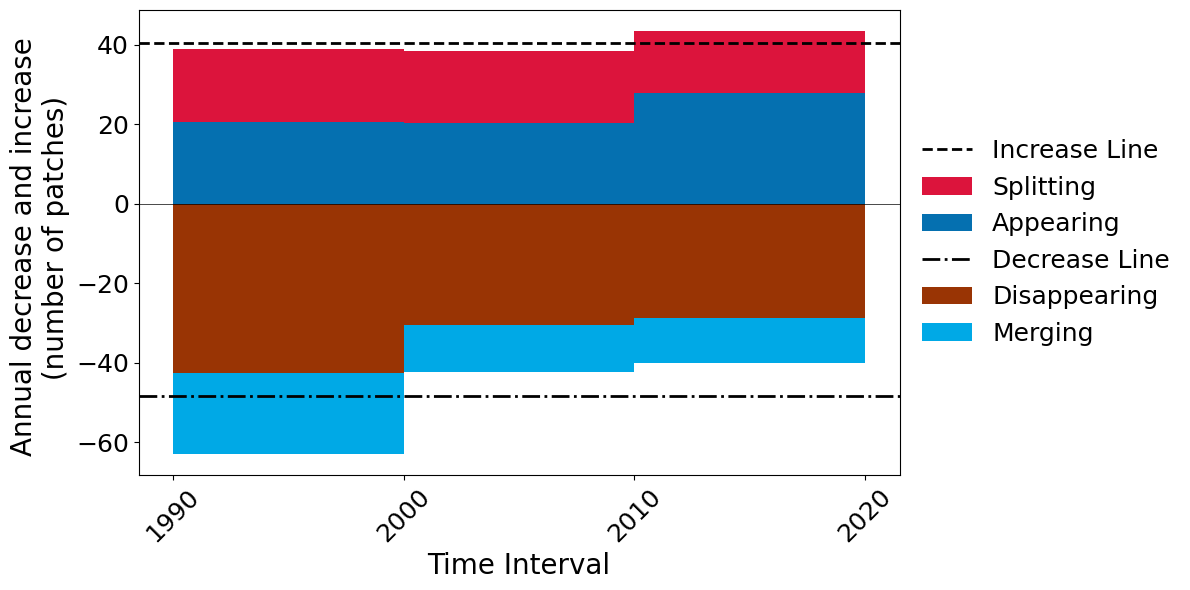

In [21]:
results = dynamicpatch.run_dynamicpatch(
    workpath=str(data_dir),
    year=[1990, 2000, 2010, 2020],
    targ_pre=2,
    in_nodata=255,
    connectivity=8,
    study_area="VCR marsh",
    unit="pixels",
    res=30,
    export_map=None,
)

DynamicPATCH displays five figures:

1. the spatial transition-pattern map;
2. the distribution of transition-patch sizes;
3. the number of transition patches by type;
4. gross area gain and loss; and
5. gross increase and decrease in patch count.

The function also returns the underlying map and tables so you can inspect or reuse them.

In [22]:
list(results.keys())

['pattern', 'patch_size', 'patch_num', 'gainloss', 'increase_decrease']

## 4. Read the four summary tables

### Patch sizes

`patch_size` contains patch-size information for every transition type and time interval. Use it to compare the typical size and variability of appearing, merging, filling, expanding, disappearing, splitting, perforating, and contracting patches.

In [27]:
results["patch_size"]

,year,Stable Absence,Appearing,Merging,Filling,Expanding,Disappearing,Splitting,Perforating,Contracting,Stable Presence
0,1990-2000,2.0,1.0,4.0,1.0,1.0,1.0,3.0,1.0,1.0,2.0
1,2000-2010,2.0,1.0,3.0,1.0,1.0,1.0,3.0,1.0,1.0,2.0
2,2010-2020,2.0,1.0,4.0,1.0,1.0,1.0,3.0,1.0,1.0,2.0


### Number of patches

`patch_num` counts the patches assigned to each transition type. A transition can occupy a large area because it has many patches, large patches, or both.

In [24]:
results["patch_num"]

,year,Stable Absence,Appearing,Merging,Filling,Expanding,Disappearing,Splitting,Perforating,Contracting,Stable Presence
0,1990,3252,206,193,2419,2527,426,185,875,3230,2313
1,2000,3193,204,148,956,1922,306,181,772,3366,2185
2,2010,3279,278,134,757,2091,288,175,1218,3518,2127


### Gross area gain and loss

`gainloss` reports the annual area associated with each transition type. The four gain types are appearing, merging, filling, and expanding. The four loss types are disappearing, splitting, perforating, and contracting.

In [25]:
results["gainloss"]

,year,Appearing,Merging,Filling,Expanding,Disappearing,Splitting,Perforating,Contracting
0,1990,57.7,464.4,489.4,652.4,-138.9,-808.6,-164.9,-994.2
1,2000,46.4,294.7,224.2,505.0,-81.4,-895.5,-146.2,-894.3
2,2010,75.7,309.3,172.6,606.2,-62.3,-710.7,-264.0,-959.4


### Gross increase and decrease in patch count

`increase_decrease` reports how appearing and splitting increase patch count, while disappearing and merging decrease patch count. These gross changes can be much larger than the net change.

In [28]:
results["increase_decrease"]

,year,Disappearing,Appearing,Splitting,Merging
0,1990,-426.0,206.0,184.0,-203.0
1,2000,-306.0,204.0,181.0,-117.0
2,2010,-288.0,278.0,156.0,-114.0


## 5. Read the results together

Use the five outputs as complementary evidence:

- **`pattern`** answers *where* each transition occurred.
- **`patch_size`** shows whether transitions occurred in small or large patches.
- **`patch_num`** shows how frequently each transition occurred.
- **`gainloss`** quantifies gross change in area.
- **`increase_decrease`** quantifies gross change in patch count.

A small net change does not mean that the landscape was stable: gross gains and gross losses may be large and may cancel each other.

## 6. Optional: export the transition map

To save a GeoTIFF, rerun the analysis with `export_map` set to an output path prefix. Do **not** include the `.tif` extension.

```python
output_prefix = Path("output/VCR_marsh_transition")
output_prefix.parent.mkdir(exist_ok=True)

# In run_dynamicpatch, replace export_map=None with:
export_map=str(output_prefix)
```

The exported file will be `output/VCR_marsh_transition.tif`.

## 7. Use your own categorical maps

For another dataset, change the input folder and the dataset-specific values below:

```python
data_dir = Path("path/to/your/maps")
years = [2000, 2010, 2020] # list of years
targ_pres = 1 # presence value 
nodata_val = 255 # no data value
res = 30 # spatial resolution in meters 
```

Input maps should represent the same location, use the same coordinate system, cell size, and extent, and have filenames that sort into the same order as `years`. Choose `connectivity=8` for queen connectivity or `connectivity=4` for rook connectivity.

The current developer branch recommends restarting the kernel before changing the input dataset or major parameters, then running the notebook again from the import cell.

## Reference

DynamicPATCH developer branch: <https://github.com/zay1996/DynamicPATCH/tree/developer-branch>

Zhang, A., Pontius Jr, R. G., Bilintoh, T. M., Sangermano, F., & Rogan, J. (2025). *DynamicPATCH: Method and software for spatially explicit dynamic patch transition characterization*. Landscape Ecology, 40(7), 132. <https://doi.org/10.1007/s10980-025-02120-1>